# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4
from qick_workspace.scrip.base_experiment import BaseExperiment
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

file_path = r'D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield'
BaseExperiment.setup(soc, soccfg, file_path)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a26a06964c834b27b9923f561f181a5d@192.168.10.82:41297
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# Qubit Setting

In [79]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q2"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

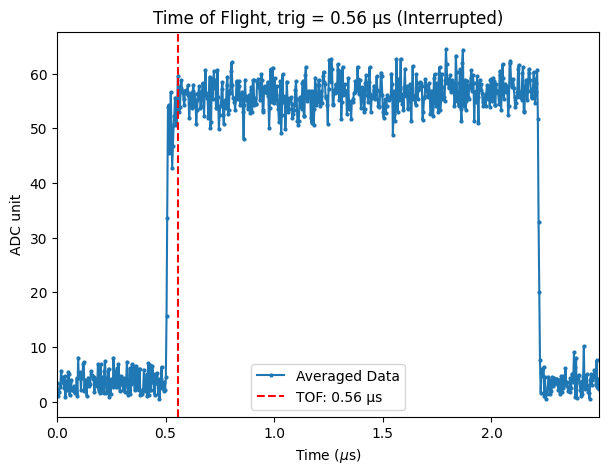

Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s001_tof_Q1_003


In [5]:
from qick_workspace.scrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        # "res_freq_ge": 3400,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 0.18,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": False,
        "relax_delay": 100,
    }
)

tof = TOF( run_cfg)
tof.run(1000)
tof.saveLabber(qubit)


In [6]:
config_all.update("trig_time", 0.49, q_index=qubit)

# YOKO Setting

In [ ]:
# from qick_workspace.tools.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [8]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

c:\Users\cluster\Desktop\SQC_soc-main\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


abcd_rf_fit result:
 {'Fres(GHz)': np.float64(7.2287), 'Qi': -8870, 'absQc': 383, 'Ql': 400, 'κ(MHz)': np.float64(18.07)}
Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s002_onetone_ge_Q2_005


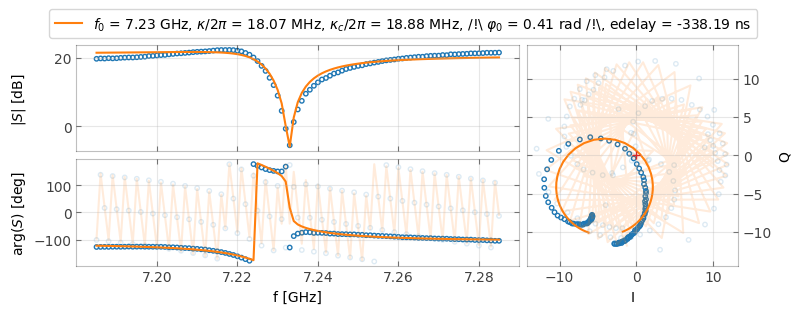

In [86]:
from qick_workspace.scrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
START_FREQ = 7235 - 50 # [MHz]
STOP_FREQ = 7235  + 50# [MHz]


STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
result = onetone.run(py_avg=5, solve_type="hm")
## update value ##
config_all.update("res_freq_ge", round(result['Fres(GHz)']*1e3, 4), q_index=qubit)
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

## OneTone PunchOut

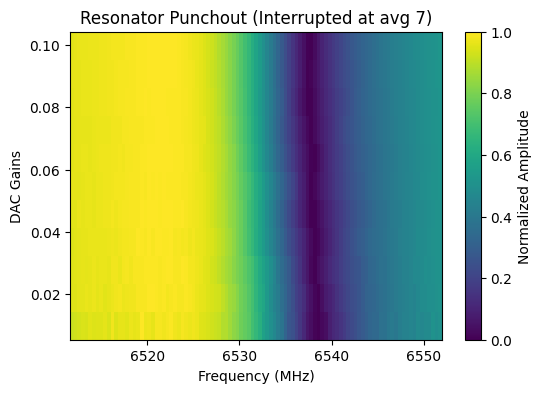

Experiment interrupted at 7 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s002b_res_ge_punchout_Q1_014


In [37]:
from qick_workspace.scrip.s002b_res_punchout_ge import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]



STEPS_freq = 101

START_gain = 0.01
STOP_gain = 0.1
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
    ]
)
punchout = Punchout(run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

Experiment interrupted at 19 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s003_qubit_spec_ge_Q2_007


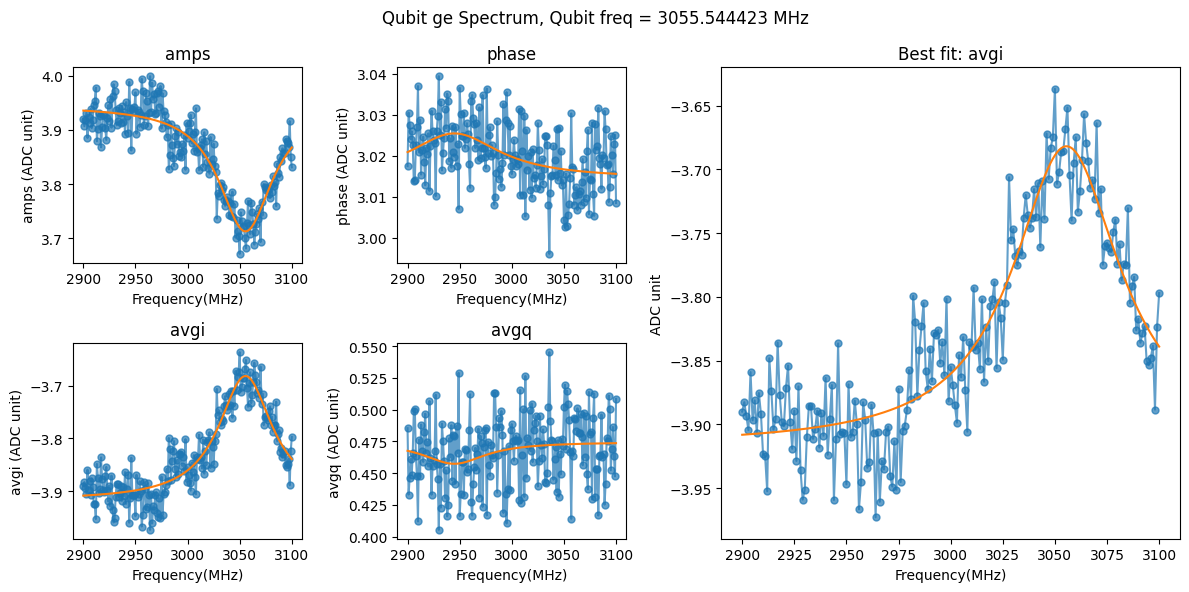

In [100]:
from qick_workspace.scrip.s003_qubit_spec_ge import QubitSpec

center = 3000
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201


config_all.update("qb_ch", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", 3),
        ("relax_delay", 1),
        ("nqz_qb", 2),
    ]
)

spectrum_ge = QubitSpec(run_cfg)
f_ge = spectrum_ge.run(50)
config_all.update("qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb_mixer", f_ge, q_index=qubit)
spectrum_ge.saveLabber(qubit, config_all=config_all)

### Fast flux spectrum

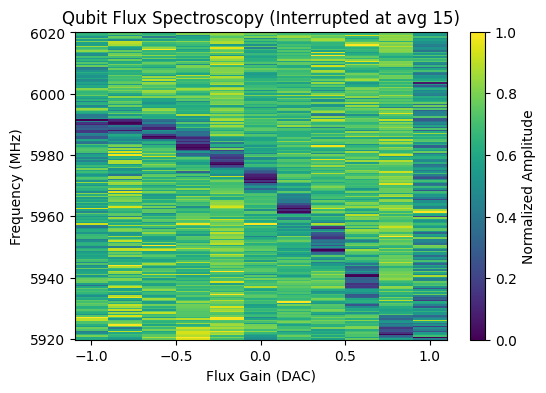

Experiment interrupted at 15 averages. Fit is based on partial data.


In [ ]:
from qick_workspace.scrip.s003a_qubit_flux_spec_ge import QubitSpecFlux

center = 5970
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

START_GAIN = -1
STOP_GAIN = 1
STEPS_GAIN = 11

config_all.update("qb_ch", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.3),
        ("qb_flat_top_length_ge", 0.5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
        ("res_length", 3),
        ("ro_length", 2.478),
        ("res_gain_ge", 0.95),
        ###################
        ("flux_ch", 15),
        ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
        ("steps_flux", STEPS_GAIN),
        ("flux_length", 0.7),
    ]
)

spectrumff_ge = QubitSpecFlux(run_cfg)
spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)


## Time Rabi ge

Experiment interrupted at 6 averages. Fit is based on partial data.


(np.float64(0.5727333650160961), np.float64(0.3290620280450587))

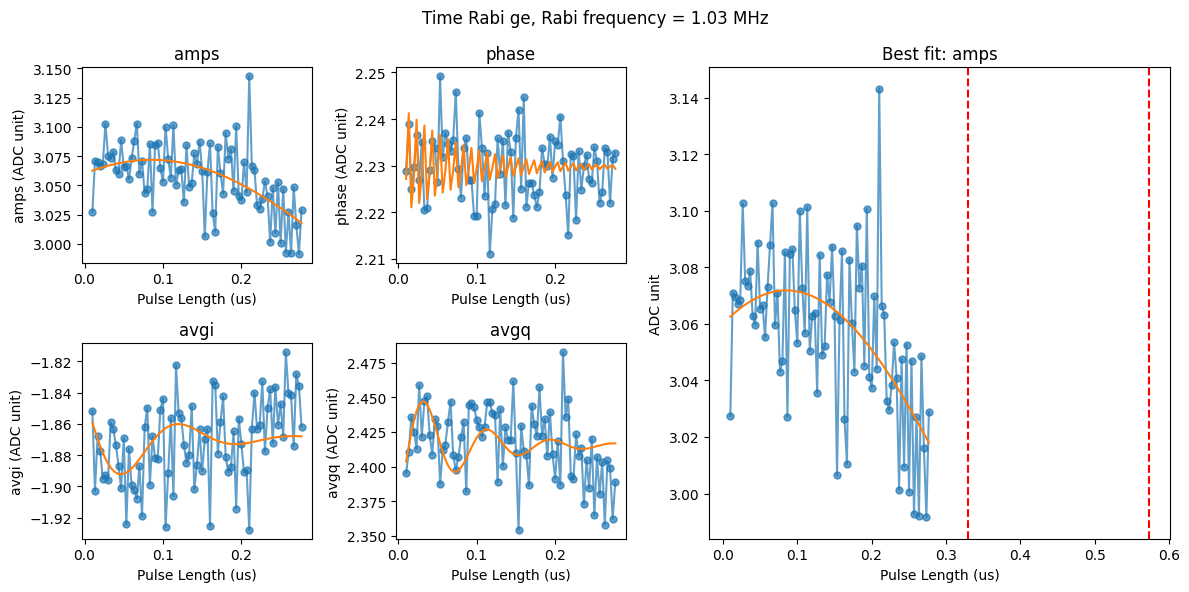

In [30]:
from qick_workspace.scrip.s004_time_rabi_ge import TimeRabi


config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 81),
    ]
)

Trabi = TimeRabi(run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 6 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s005_power_rabi_ge_Q2_006


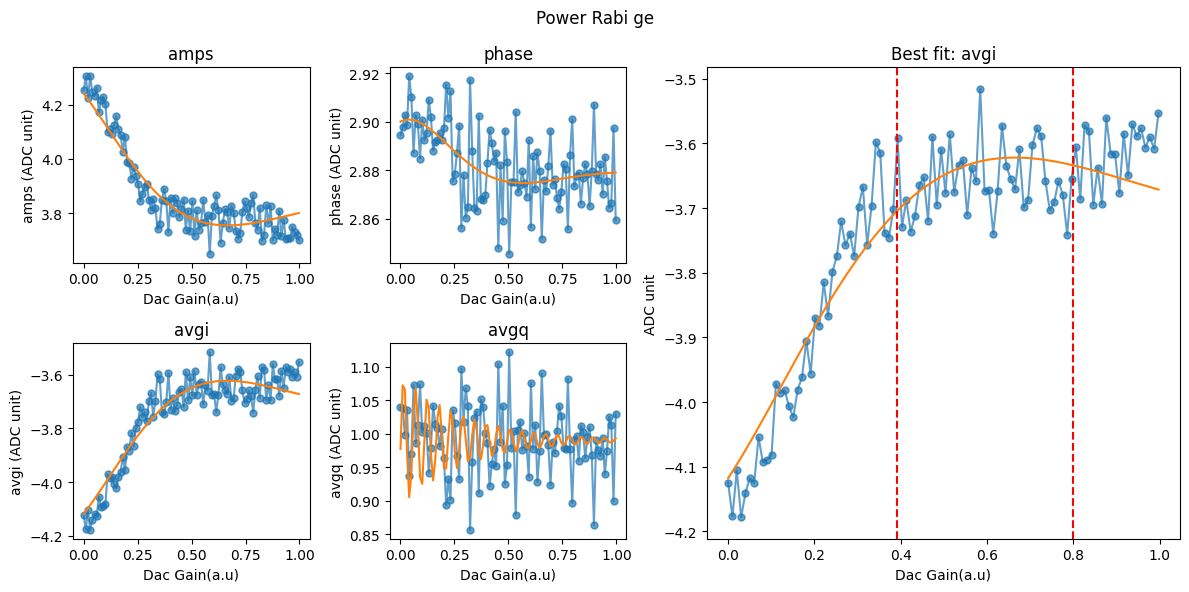

In [102]:
from qick_workspace.scrip.s005_power_rabi_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("nqz_qb", 2, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        # ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.1),
    ]
)

prabi = PowerRabi(run_cfg)
pi_gain, pi2_gain = prabi.run(50)
config_all.update("pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=qubit)
prabi.saveLabber(qubit, config_all=config_all)

## Amplified Amplitude Error (AAE)

Interrupted at iteration 15.

[PowerRabi] Optimal pi gain = 0.360309


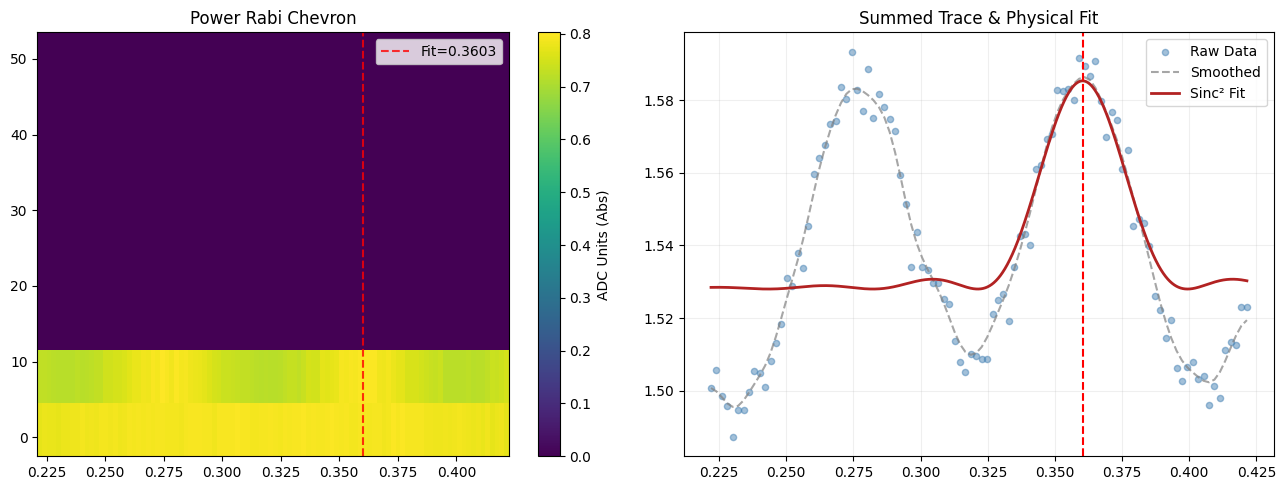

Data saved to c:\Users\cluster\Desktop\SQC_soc-master\test\2026\04\Data_0409\s005_power_rabi_chevron_Q1_001


In [18]:
from qick_workspace.scrip.s005a_AAE import PowerRabiChevron

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
focus = run_cfg['pi_gain_ge']
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", focus-0.1, focus+0.1)),
        # ("pulse_type", "drag"),
        ("iter_start", 1),
        ("iter_stop", 50),
        ("iter_step", 7),
        # ("qb_flat_top_length_ge", 0.1),

    ]
)

prabichevron = PowerRabiChevron(run_cfg)
result = prabichevron.run(10)
config_all.update("pi_gain_ge", result, q_index=qubit)
config_all.update("pi2_gain_ge", result / 2, q_index=qubit)
prabichevron.saveLabber(qubit, config_all=config_all)

## Ramsey ge

Experiment interrupted at 12 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s006_Ramsey_ge_Q2_002


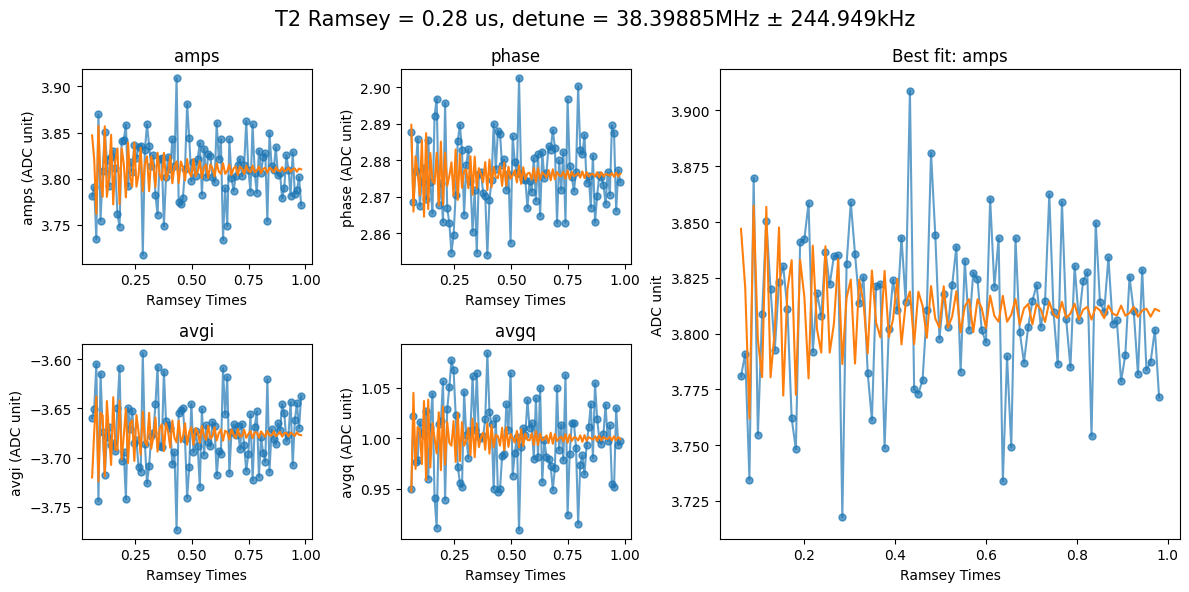

In [103]:
from qick_workspace.scrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 1 # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq",5),
        # ("pulse_type", "drag"),
    ]
)

t2r = Ramsey(run_cfg)
t2r.run(20)
t2r.saveLabber(qubit, config_all=config_all)

In [110]:
t2r.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s006_Ramsey_ge_Q2_003


In [93]:
config_all.update("qb_freq_ge", t2r.correct_detune(), qubit)

over detune 0.19217MHz


## Spin Echo

Experiment interrupted at 2 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s007_SpinEcho_ge_Q1_001


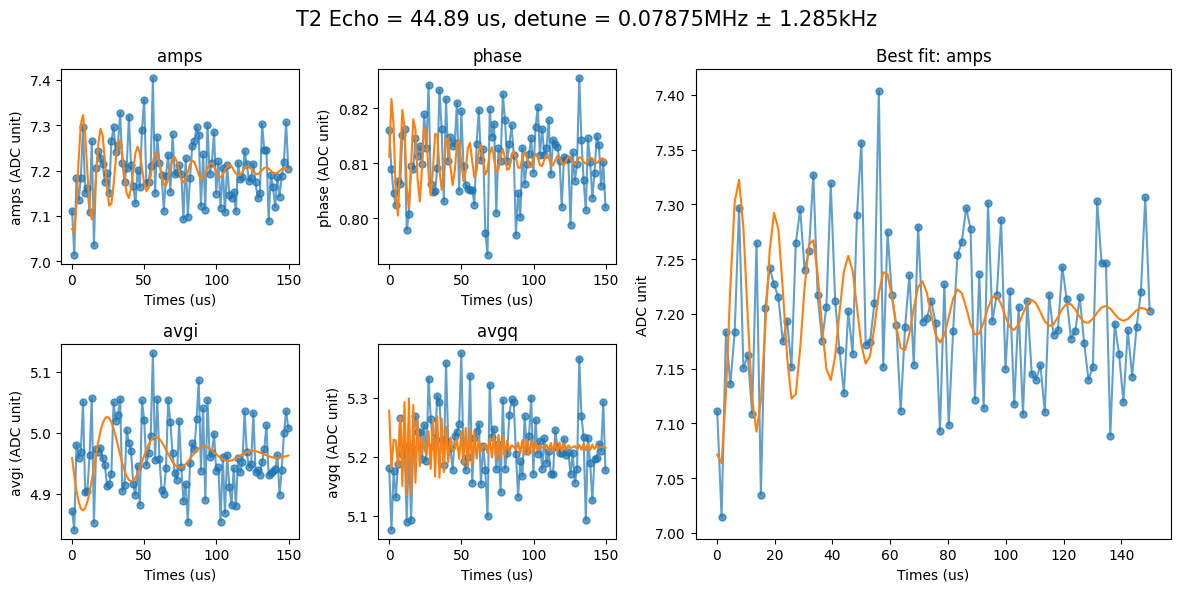

In [53]:
from qick_workspace.scrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 150  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.05),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(run_cfg)
t2e.run(100)
t2e.saveLabber(qubit, config_all=config_all)

## T1 ge

Experiment interrupted at 10 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s008_T1_ge_Q2_001


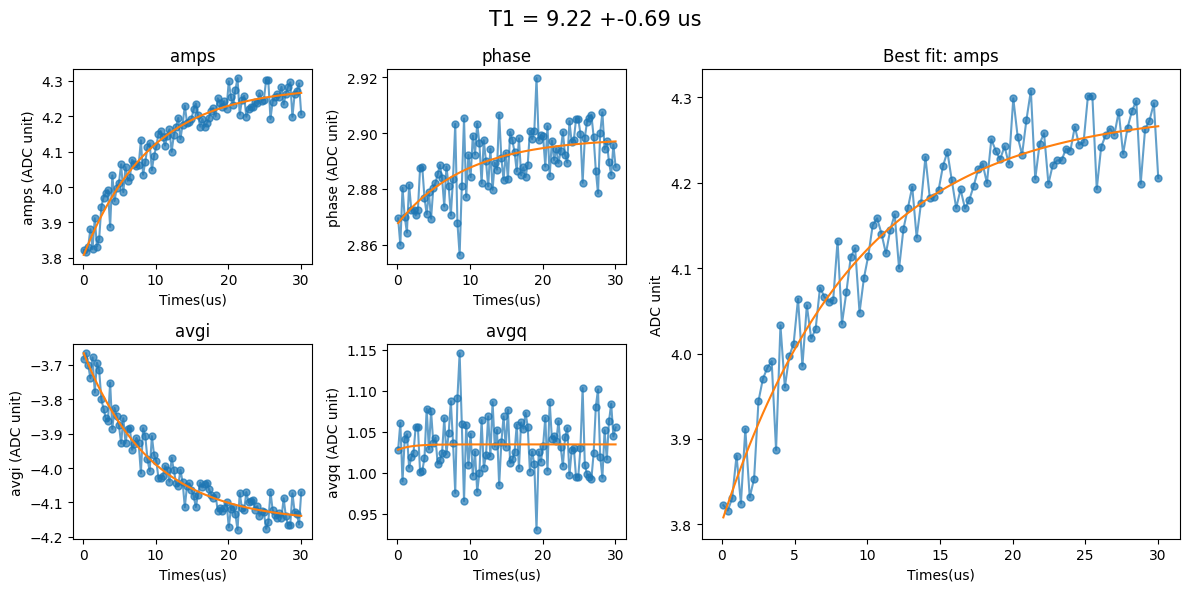

In [104]:
from qick_workspace.scrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 30  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ('pulse_type', "drag"),
    ]
)

t1 = T1(run_cfg)
t1.run(50)
t1.saveLabber(qubit, config_all=config_all)

## Single Shot

  0%|          | 0/5000 [00:00<?, ?it/s]

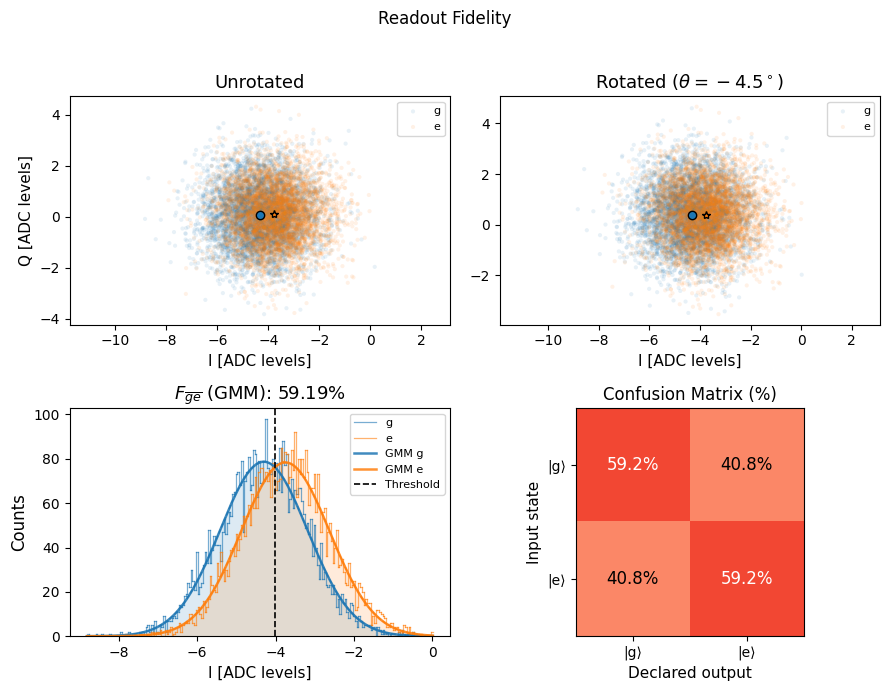

Rotation angle : -4.51 deg
GMM Fidelity   : 59.190%
  |g⟩  components=1  primary_mean=-4.300  primary_std=1.120  secondary_weight=0.000
  |e⟩  components=1  primary_mean=-3.749  primary_std=1.125  secondary_weight=0.000
Thresholds     : ['-4.017']
Confusion Matrix (%):
 [[59.2 40.8]
 [40.8 59.2]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\commercial_sample_holder_wo_rshield\2026\04\Data_0420\s000_singleshot_ge_Q2_001


In [105]:
from qick_workspace.scrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase',0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update('res_phase', ssh_result[2], q_index=qubit)
ssh.saveLabber(qubit)

### ssh opt

Length loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/5 [00:00<?, ?it/s]

Analyze [GMM fidelity (ge)]:   0%|          | 0/5 [00:00<?, ?it/s]


25/25 grid points pass physical constraints (leakage <= 0.2, thermal <= 0.1)

--- Grid best (feasible) ---
  fid=0.6340  soft=0.5471  SNR=0.205  leakage=0.000  thermal=0.000
  length=1.3  gain=0.1  freq=7228.7

--- GP interpolation result ---
  predicted fid = 0.6265
  length=1.3000  gain=0.100000  freq=7228.700000

=== Pareto front (fidelity vs leakage): 1 points ===
      fid    leak   therm    length        gain        freq
  0.5850  0.0000  0.0000       0.7         0.1      7228.7


  0%|          | 0/5000 [00:00<?, ?it/s]

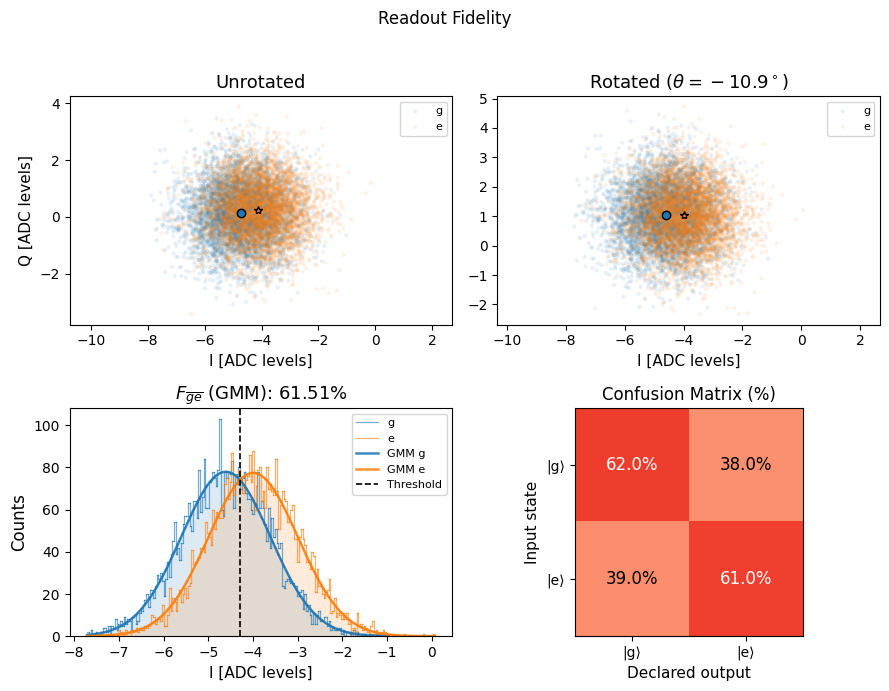

Rotation angle : -10.90 deg
GMM Fidelity   : 61.510%
  |g⟩  components=1  primary_mean=-4.609  primary_std=0.996  secondary_weight=0.000
  |e⟩  components=1  primary_mean=-3.997  primary_std=1.003  secondary_weight=0.000
Thresholds     : ['-4.296']
Confusion Matrix (%):
 [[62. 38.]
 [39. 61.]]


In [109]:
from qick_workspace.scrip.s000_SingleShot_opt import SingleShot_ge_opt

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 3, run_cfg["res_freq_ge"] + 3, 11)
gain_axis = np.linspace(0.1, 0.2, 5)
length_axis = np.linspace(0.5, 1.3, 5)
sweep_para = {"freq":run_cfg["res_freq_ge"], "gain": gain_axis, "length": length_axis}


SHOT = 2000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase',0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update('res_phase', ssh_result[2], q_index=qubit)

# EF State

## Resonator OneTone ef

Experiment interrupted at 3 averages. Fit is based on partial data.


c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.8116),
 'Qi': -28546,
 'Ql': 1286,
 'absQc': 1231,
 'κ(MHz)': np.float64(5.3)}


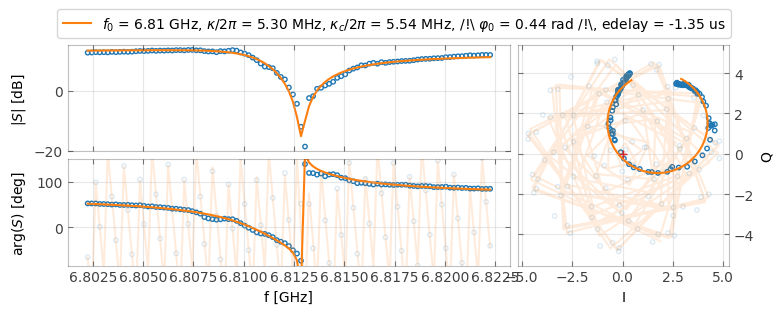

In [ ]:
from qick_workspace.scrip.s009_res_spec_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),

    ]
)

onetone_ef = ResonatorSpec_ef(run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 2 averages. Fit is based on partial data.


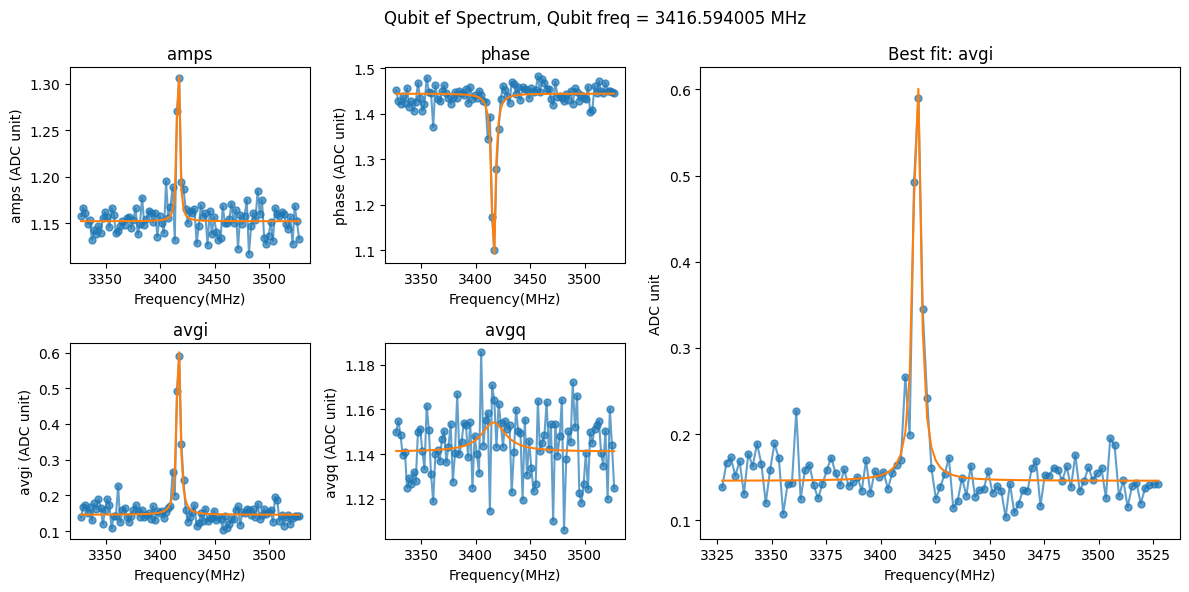

In [29]:
from qick_workspace.scrip.s010_qubit_spec_ef import QubitSpec_ef

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 101
config_all.update("qb_ch_ef", 0, q_index=qubit)
config_all.update("nqz_qb_ef", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.3),
        ("qb_flat_top_length_ef", 2),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpec_ef(run_cfg)
f_ef = spectrum_ef.run(10)
config_all.update("qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ef

Experiment interrupted at 2 averages. Fit is based on partial data.
Data saved to c:\Users\cluster\Desktop\SQC_soc-master\test\2026\04\Data_0409\s011_power_rabi_ef_Q1_001


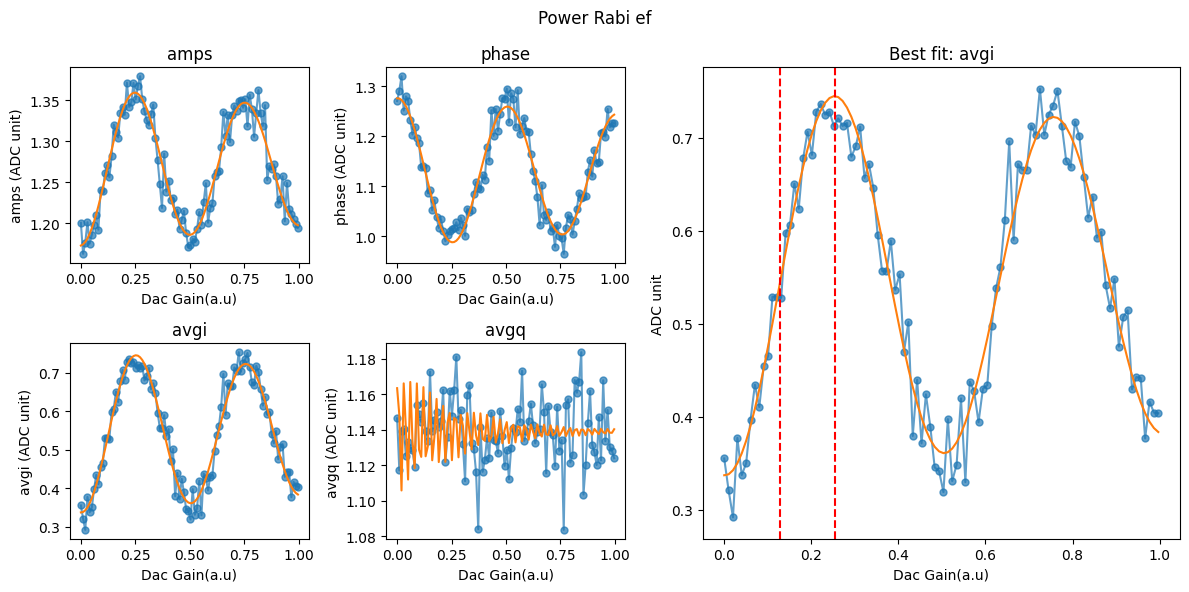

In [31]:
from qick_workspace.scrip.s011_power_rabi_ef import PowerRabi_ef

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabi_ef(run_cfg)
pi_gain_ef, pi2_gain_ef = prabi_ef.run(50)
config_all.update("pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

[Temp] A_meas=0.0229  A_ref=0.0661  ratio=2.8918
[Temp] Estimated temperature: 163.93 mK


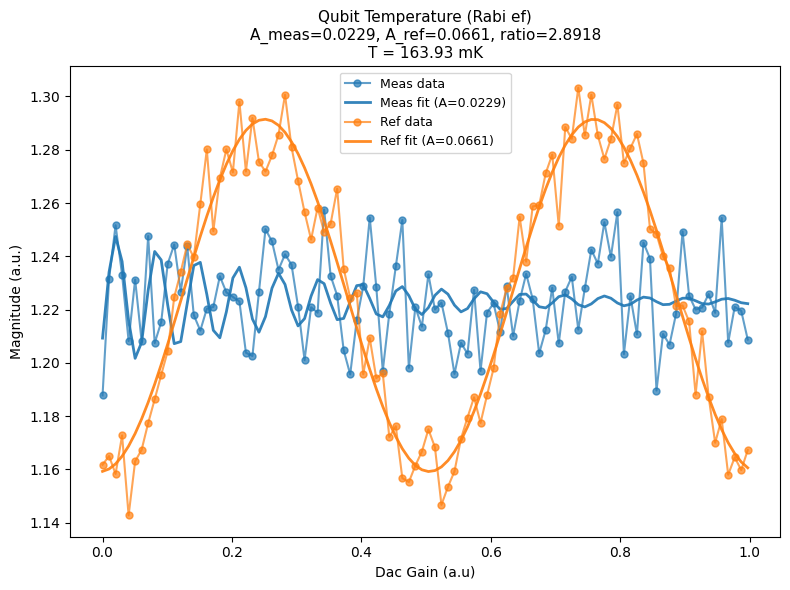

np.float64(0.1639339086104994)

In [ ]:
from qick_workspace.scrip.s013_qubit_temp import QubitTemperatureEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)
config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
        ("ro_length", 2),
    ]
)
rabi_temp = QubitTemperatureEf(run_cfg)
rabi_temp.run(5)
# rabi_temp.saveLabber(qubit, config_all=config_all)

## Ramsey ef

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to c:\Users\cluster\Desktop\SQC_soc-master\test\2026\04\Data_0409\s012_Ramsey_ef_Q1_001


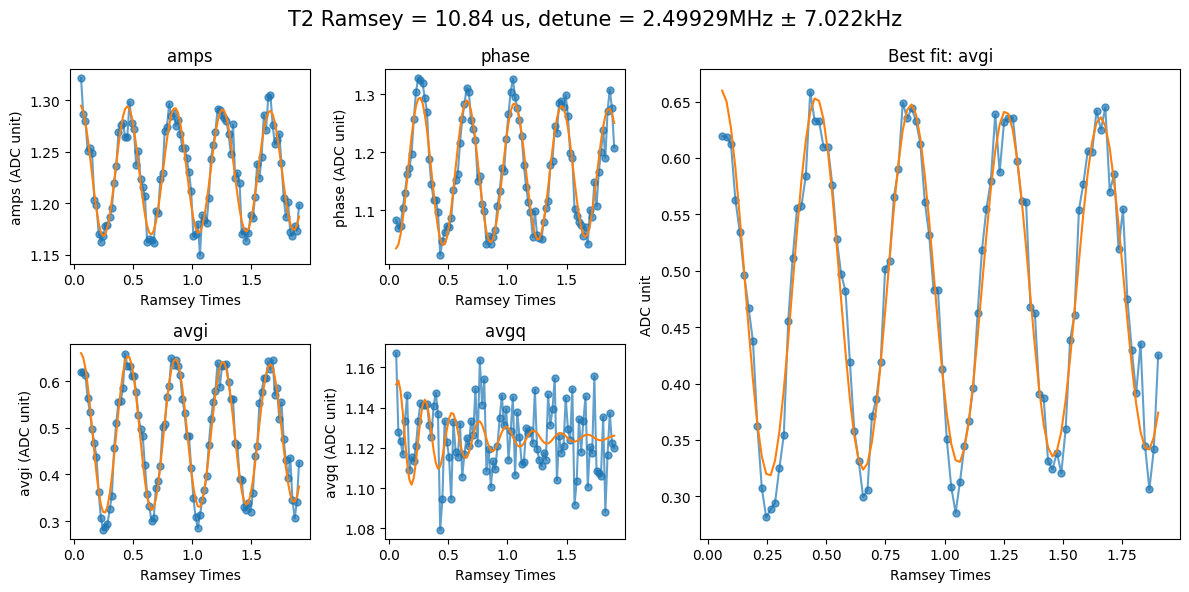

In [34]:
from qick_workspace.scrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ("ge_ref", True),

    ]
)

t2r_ef = Ramsey_ef(run_cfg)
t2r_ef.run(100)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [35]:
config_all.update("qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune 0.49929MHz


## T1 ef

Experiment interrupted at 3 averages. Fit is based on partial data.


c:\Users\cluster\Desktop\SQC_soc-master\qick_workspace\tools\fitting.py:404: RuntimeWarning: overflow encountered in exp
  return y0 + yscale * np.exp(-x / decay)


Data saved to c:\Users\cluster\Desktop\SQC_soc-master\test\2026\04\Data_0409\s013_T1_ef_Q1_001


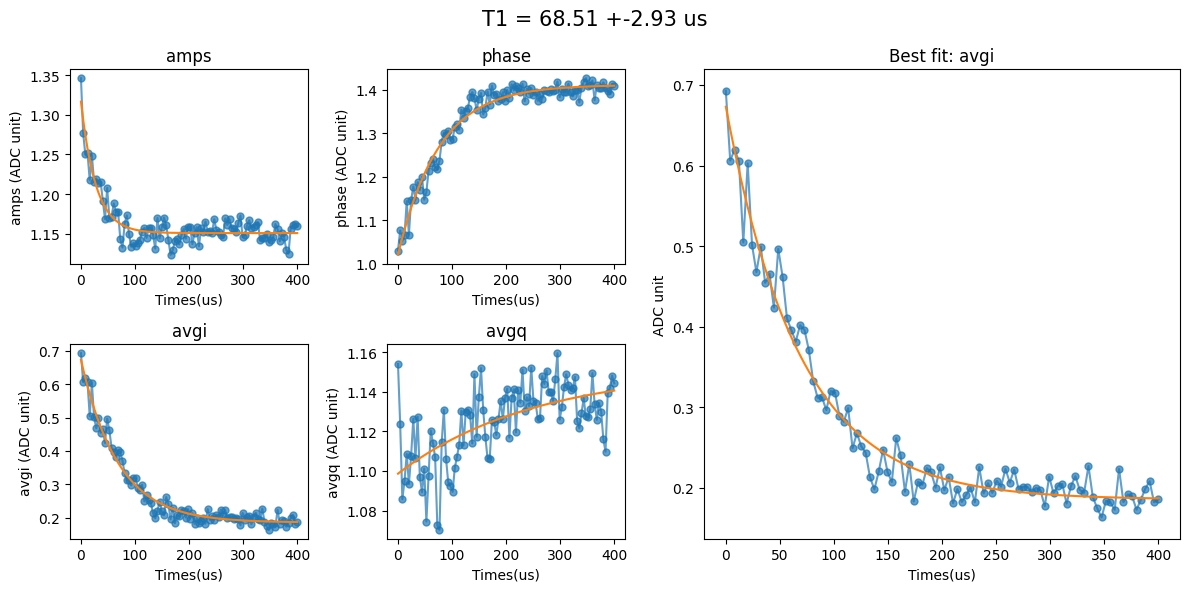

In [36]:
from qick_workspace.scrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),

    ]
)

t1_ef = T1_ef(run_cfg)
t1_ef.run(50)
t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/5000 [00:00<?, ?it/s]

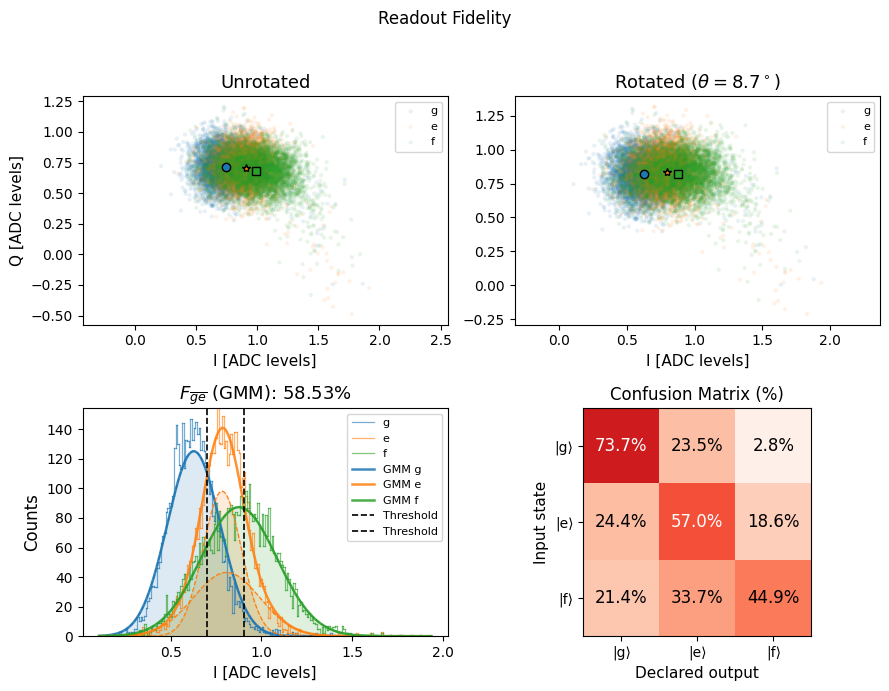

Rotation angle : 8.71 deg
GMM Fidelity   : 58.527%
  |g⟩  components=1  primary_mean=0.627  primary_std=0.146  secondary_weight=0.000
  |e⟩  components=2  primary_mean=0.783  primary_std=0.105  secondary_weight=0.433  ⚠ secondary component large — possible state leakage
  |f⟩  components=1  primary_mean=0.876  primary_std=0.209  secondary_weight=0.000
Thresholds     : ['0.701', '0.906']
Confusion Matrix (%):
 [[73.7 23.5  2.8]
 [24.4 57.  18.6]
 [21.4 33.7 44.9]]


[[0.5852666666666667],
 [0.7012181435222175, 0.9062275449623468],
 np.float64(8.71319070844505),
 array([[73.68, 23.48,  2.84],
        [24.4 , 57.  , 18.6 ],
        [21.42, 33.68, 44.9 ]])]

In [ ]:
from qick_workspace.scrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = 'drag'

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)

Length loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/3 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

...

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Freq loop:   0%|          | 0/4 [00:00<?, ?it/s]

Analyze AUC fidelity (gef avg pairwise):   0%|          | 0/4 [00:00<?, ?it/s]


--- Grid Search Result ---
Max fidelity (on grid): 0.8868
At length=4.000 us, gain=0.07500 DAC, freq=6722.38442 MHz

Returning grid search result.


  0%|          | 0/5000 [00:00<?, ?it/s]

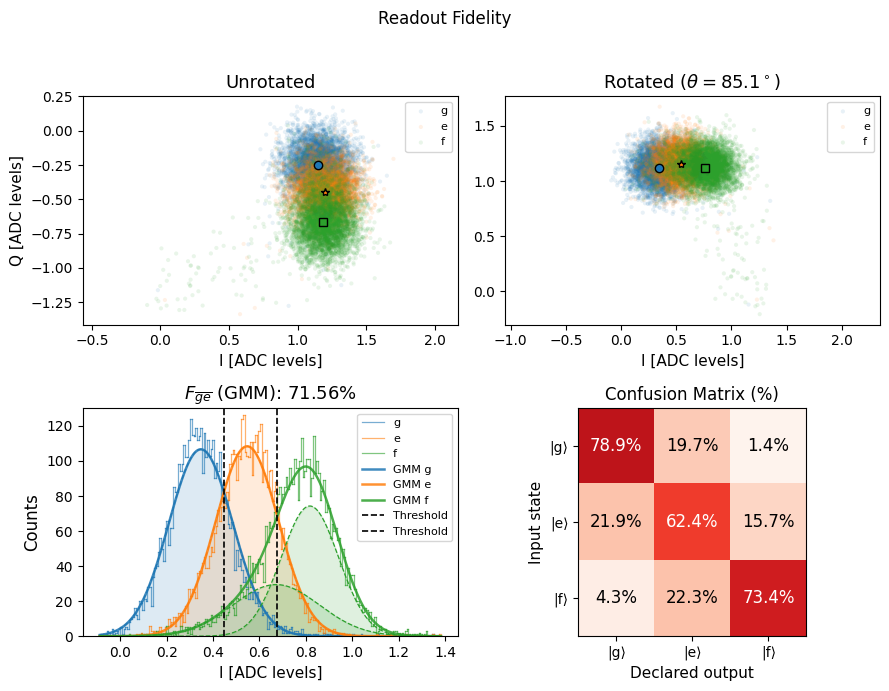

Rotation angle : 85.06 deg
GMM Fidelity   : 71.560%
  |g⟩  components=1  primary_mean=0.347  primary_std=0.138  secondary_weight=0.000
  |e⟩  components=1  primary_mean=0.547  primary_std=0.135  secondary_weight=0.000
  |f⟩  components=2  primary_mean=0.817  primary_std=0.124  secondary_weight=0.374  ⚠ secondary component large — possible state leakage
Thresholds     : ['0.446', '0.676']
Confusion Matrix (%):
 [[78.9 19.7  1.4]
 [21.9 62.4 15.7]
 [ 4.3 22.3 73.4]]


[[0.7155999999999999],
 [0.44618972797883893, 0.6764287993674554],
 np.float64(85.05918830180241),
 array([[78.92, 19.66,  1.42],
        [21.94, 62.4 , 15.66],
        [ 4.3 , 22.34, 73.36]])]

In [ ]:
from qick_workspace.scrip.s000_SingleShot_opt import SingleShot_ge_opt
USE_DRAG = True


run_cfg = config_all.get_qubit(qubit)
if USE_DRAG:
    run_cfg['pulse_type'] = "drag"

freq_axis = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 5, 4)
gain_axis = np.linspace(0.05, 0.1, 3)
length_axis = np.linspace(1, 4, 4)
sweep_para = {"freq":freq_axis, "gain": gain_axis, "length": length_axis}


SHOT = 1000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para, shot_f=True)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length", length, q_index=qubit)
config_all.update("res_gain_ge", gain, q_index=qubit)
config_all.update("res_freq_ge", freq, q_index=qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase',0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

if USE_DRAG:
    run_cfg['pulse_type'] = "drag"

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)


# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

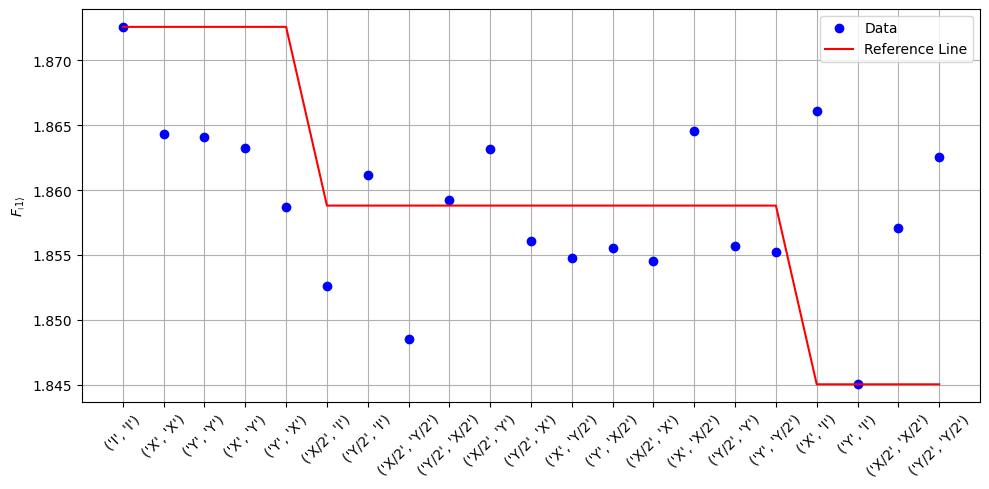

In [ ]:
from qick_workspace.scrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)

run_cfg.update([
    # ("pulse_type", "drag"),
])
allxy = AllXY(run_cfg)
allxy.run(10)
allxy.plot()

### Drag allxy

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

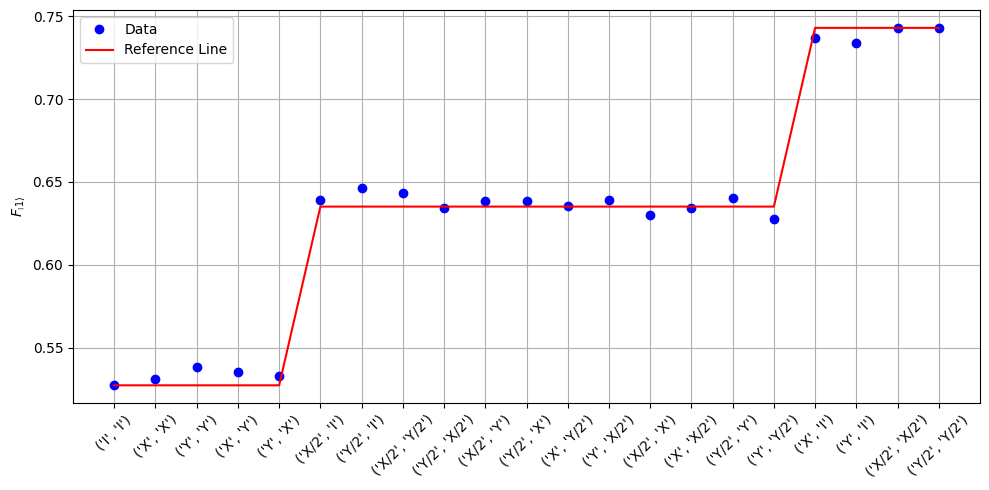

In [ ]:
from qick_workspace.scrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("pulse_type", "drag"),
])
allxy = AllXY(run_cfg)
allxy.run(10, iq_process='real')
allxy.plot()

## State tomography 

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (0.15265581773799836+1.1473555736371035j), IQ Excited: (0.3892969894222945+1.184820179007323j)


Tomography (x180):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=-0.1293, <Y>=0.0301, <Z>=-1.0000
Purity: 1.00000


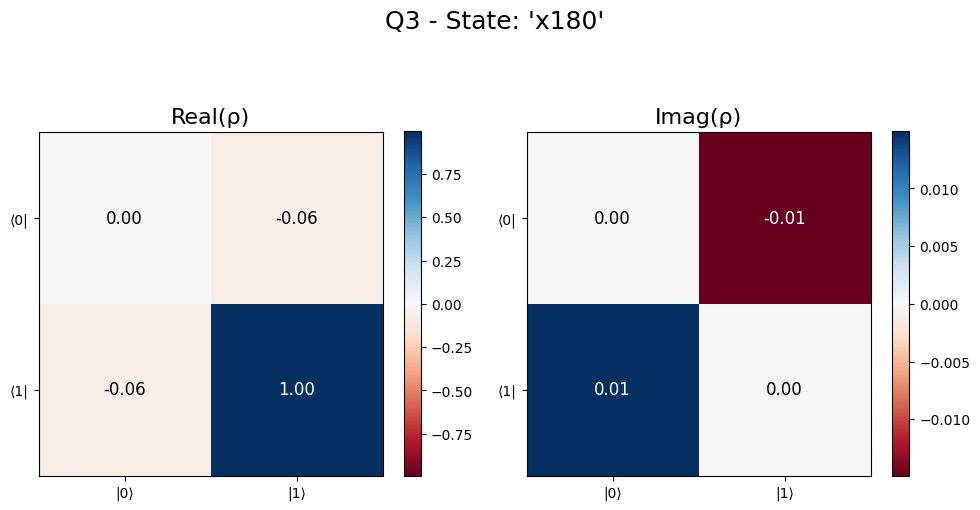

c:\Users\cluster\Desktop\SQC_soc-master\qick_workspace\newscrip\s016_state_tomography.py:201: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


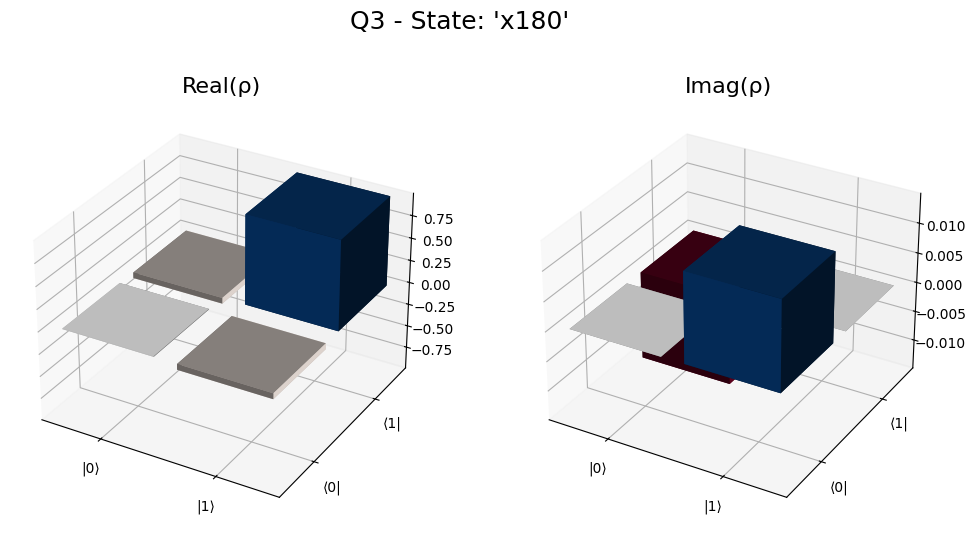

(<Figure size 1200x600 with 2 Axes>, None)

In [37]:
from qick_workspace.scrip.s016_state_tomography import Tomography

pyavg = 5

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x180")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking


=== Standard RB (Reference) ===


Standard RB:   0%|          | 0/12 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

[fitrb] p=0.999968  a=0.3782  b=0.2787
[fitrb] σ(p)=6.82e-02  σ(a)=8.09e+02  σ(b)=8.09e+02
  p        = 99.9968 ± 6.8163 %
  F_gate   = 100.2810 ± 3.4323 %
  EPC      = -0.2810 ± 3.4323 %


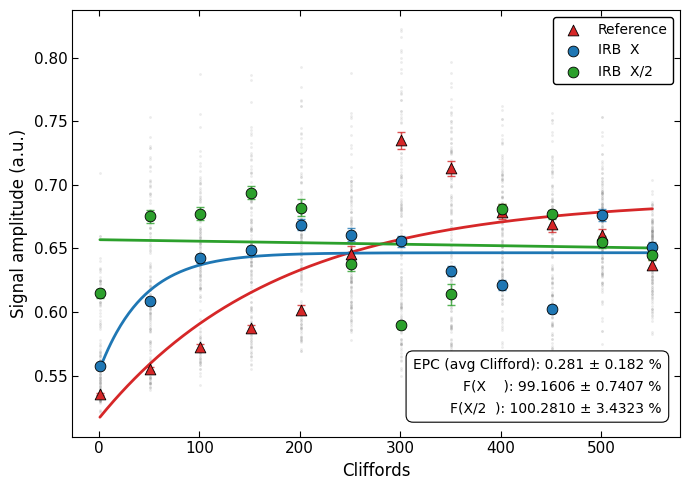

RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s015_RB_Q1_ref_024
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s015_RB_X_Q1_013
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0409\s015_RB_halfX_Q1_015
  AutoRB Summary
  Reference EPC : 0.2810 ± 0.1823 %
  p (decay)     : 99.4380 ± 0.3646 %

  Gate fidelities:
    X       F = 99.1606 ± 0.7407 %  (EPC = 0.8394 %)
    X/2     F = 100.2810 ± 3.4323 %  (EPC = -0.2810 %)


In [ ]:
from qick_workspace.scrip.s015_Auto_RB import AutoRB

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"

auto = AutoRB(run_cfg)
interleaved = ["X", "X/2"]
auto.run(
    py_avg=5,
    max_circuit_depth=600,
    delta_clifford=50,
    number_sample=50,
    interleaved_gates=interleaved,
    iq_process='real'
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())


--- Running Standard RB (Ref) ---


Standard RB:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

Samples:   0%|          | 0/30 [00:00<?, ?it/s]

[fitrb] p=0.970587  a=-0.1784  b=0.4414
[fitrb] σ(p)=1.55e-02  σ(a)=3.74e-02  σ(b)=1.36e-02

--- Ref ---
  p   = 97.058692 ± 1.549313 %
  EPC = 1.470654 ± 0.774656 %
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s015_RB_Q1_ref_021


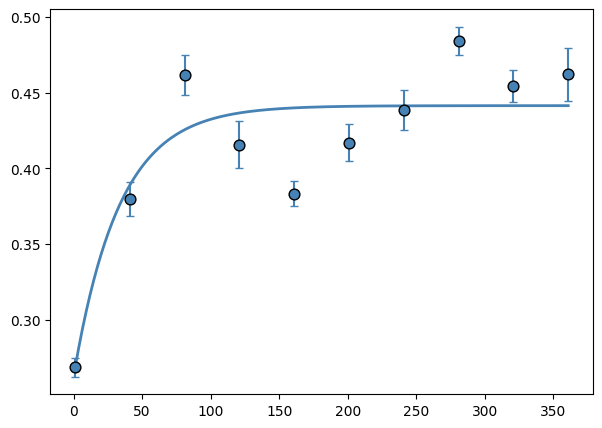

In [77]:
from qick_workspace.scrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"


py_avg = 5
max_circuit_depth = 400
delta_clifford = 40
number_sample = 30

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

In [18]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
# interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
interleaved_gates_to_test = ["X/2"]


for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)


--- Running Interleaved RB (X/2) ---


IRB (X/2):   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Samples:   0%|          | 0/50 [00:00<?, ?it/s]

RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s015_RB_halfX_Q1_012


# Drag


[DRAG Sum] Optimal α = 0.422481)


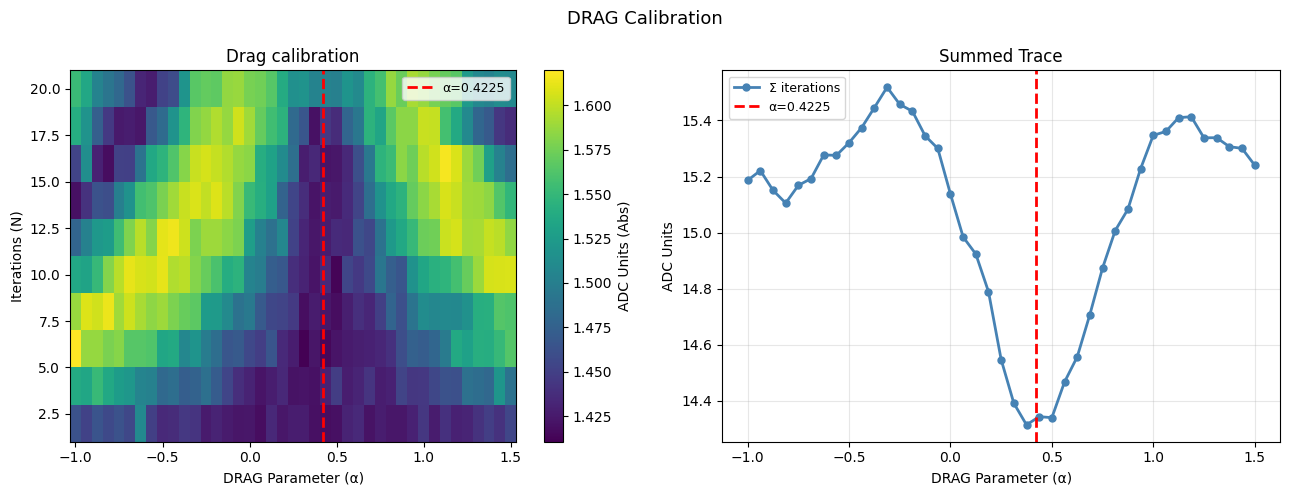

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0408\s005a_drag_ge_Q1_013


In [ ]:
from qick_workspace.scrip.s005a_drag import DragCalibration

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        # Alpha
        ("alpha_start", -1),
        ("alpha_stop", 1.5),
        ("alpha_steps", 41), 
        # Iterationi
        ("iter_start", 2),
        ("iter_stop", 20),
        ("iter_step", 2),
    ]
)

drag_cal = DragCalibration(run_cfg)
fit_results = drag_cal.run(py_avg=5)

config_all.update("drag_alpha", fit_results['optimal_alpha'], q_index=qubit)
drag_cal.saveLabber(qubit, config_all=config_all)